#Proyecto final Machine learning II:
#Predicción de coincidencias en speed dating mediante modelos de clasificación



# 1. Introducción al dataset y los objetivos

El dataset Speed Dating Data recoge información de varios eventos de citas rápidas en los que diferentes participantes evaluaban a las personas con las que interactuaban. En total, incluye datos sobre características personales, preferencias y valoraciones realizadas durante los encuentros.

El objetivo de este trabajo es construir un modelo de clasificación que permita predecir si dos personas harán match o no, utilizando como variable objetivo *match*. Para ello, se emplearán distintas técnicas de aprendizaje supervisado a partir de variables como la edad, intereses, atractivo o personalidad.

Este análisis es interesante porque permite entender qué factores pueden influir en que dos personas decidan volver a verse, además de aplicar conceptos de machine learning en un contexto real y cercano.

El dataset ha sido obtenido de Kaggle:
https://www.kaggle.com/datasets/annavictoria/speed-dating-experiment

# 2. Exploración del dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset (usamos latin1 porque daba error con utf-8)
df = pd.read_csv("Speed Dating Data.csv", encoding='latin1')

df.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# El dataset contiene un total de 195 variables, lo que puede complicar el análisis,
# por lo que será necesario seleccionar variables relevantes.
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (8378, 195)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), object(8)
memory usage: 12.5+ MB


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
count,8378.000000,8377.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,8378.000000,6532.000000,8378.000000,...,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
mean,283.675937,8.960248,0.500597,17.327166,1.828837,11.350919,16.872046,9.042731,9.295775,8.927668,...,7.240312,8.093357,8.388777,7.658782,7.391545,6.810020,7.615079,7.932540,7.155258,7.048611
std,158.583367,5.491329,0.500029,10.940735,0.376673,5.995903,4.358458,5.514939,5.650199,5.477009,...,1.576596,1.610309,1.459094,1.744670,1.961417,1.507341,1.504551,1.340868,1.672787,1.717988
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000
25%,154.000000,4.000000,0.000000,8.000000,2.000000,7.000000,14.000000,4.000000,4.000000,4.000000,...,7.000000,7.000000,8.000000,7.000000,6.000000,6.000000,7.000000,7.000000,6.000000,6.000000
50%,281.000000,8.000000,1.000000,16.000000,2.000000,11.000000,18.000000,8.000000,9.000000,8.000000,...,7.000000,8.000000,8.000000,8.000000,8.000000,7.000000,8.000000,8.000000,7.000000,7.000000
75%,407.000000,13.000000,1.000000,26.000000,2.000000,15.000000,20.000000,13.000000,14.000000,13.000000,...,8.000000,9.000000,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,8.000000,8.000000
max,552.000000,22.000000,1.000000,44.000000,2.000000,21.000000,22.000000,22.000000,22.000000,22.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [ ]:
cols = list(df.columns)
print(cols)

['iid', 'id', 'gender', 'idg', 'condtn', 'wave', 'round', 'position', 'positin1', 'order', 'partner', 'pid', 'match', 'int_corr', 'samerace', 'age_o', 'race_o', 'pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha', 'dec_o', 'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o', 'age', 'field', 'field_cd', 'undergra', 'mn_sat', 'tuition', 'race', 'imprace', 'imprelig', 'from', 'zipcode', 'income', 'goal', 'date', 'go_out', 'career', 'career_c', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'exphappy', 'expnum', 'attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1', 'attr4_1', 'sinc4_1', 'intel4_1', 'fun4_1', 'amb4_1', 'shar4_1', 'attr2_1', 'sinc2_1', 'intel2_1', 'fun2_1', 'amb2_1', 'shar2_1', 'attr3_1', 'sinc3_1', 'fun3_1', 'intel3_1', 'amb3_1', 'attr5_1', 'sinc5_1', 'intel5_1', 'fun5_1', 'amb5_1', 'de

In [ ]:
df.columns = df.columns.str.lower().str.strip()

In [ ]:
# Seleccionar solo variables importantes para reducir ruido
cols = [
    'match',
    'age', 'age_o', 'gender', 'samerace', 'field',

    'attr', 'sinc', 'intel', 'fun', 'amb', 'shar',
    'attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o',

    'like', 'prob', 'met', 'int_corr',

    'sports', 'tvsports', 'exercise', 'dining',
    'museums', 'art', 'hiking', 'gaming',
    'clubbing', 'reading', 'tv', 'movies',
    'concerts', 'music', 'shopping', 'yoga',

    # estas variables son solo para análisis, no para entrenar el modelo porque
    # se podrá saber quienes llaman o vuelven a tener una cita de los que han hecho match por ejemplo
    'you_call', 'them_cal', 'date_3', 'numdat_3'
]

df = df[cols]

In [ ]:
# Se cambian nombres  de las columnas para que el análisis sea más fácil de entender
# y más claro al presentar el proyecto.

df = df.rename(columns={
    'age_o': 'partner_age',
    'attr': 'attractiveness',
    'sinc': 'sincerity',
    'intel': 'intelligence',
    'fun': 'fun_score',
    'amb': 'ambition',
    'shar': 'shared_interests',

    'attr_o': 'partner_attractiveness',
    'sinc_o': 'partner_sincerity',
    'intel_o': 'partner_intelligence',
    'fun_o': 'partner_fun',
    'amb_o': 'partner_ambition',
    'shar_o': 'partner_shared_interests',

    'prob': 'perceived_probability',
    'met': 'met_before',
    'int_corr': 'interest_correlation',

    'excersice': 'exercise',
    'you_call': 'called_matches',
    'them_cal': 'received_calls',
    'date_3': 'had_date_after',
    'numdat_3': 'num_dates_after'
})

In [ ]:
# comprobación de duplicados  y eliminación de ellos
df.duplicated().sum()

df = df.drop_duplicates()
#No se presentan duplicados

## Nans

El tratamiento de valores nulos se realizó teniendo en cuenta el significado de cada variable. En variables de seguimiento posterior al evento como called after, los valores nulos se interpretaron como ausencia del evento (no llamadas o no citas), por lo que se consideran como 0.

En variables de evaluación, como atractivo o inteligencia, se utilizó la mediana para evitar sesgos. Las variables categóricas se trataron con la categoría "unknown", y en variables binarias se asumió el valor 0 cuando no había información disponible.

In [ ]:
# Contar nulos
Nans = df.isnull().sum()
Nans = Nans[Nans > 0].sort_values(ascending=False)

# Porcentaje de nulos
Nans_pct = (df.isnull().sum() / len(df)) * 100
Nans_pct = Nans_pct[Nans_pct > 0].sort_values(ascending=False)

pd.DataFrame({'Nans': Nans, '%': Nans_pct})

,Nans,%
num_dates_after,6881,82.141578
called_matches,4403,52.560583
received_calls,4403,52.560583
had_date_after,4403,52.560583
partner_shared_interests,1075,12.832756
shared_interests,1066,12.725319
partner_ambition,721,8.606900
ambition,711,8.487525
met_before,374,4.464605
partner_fun,359,4.285544


/tmp/ipykernel_337/1051525128.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


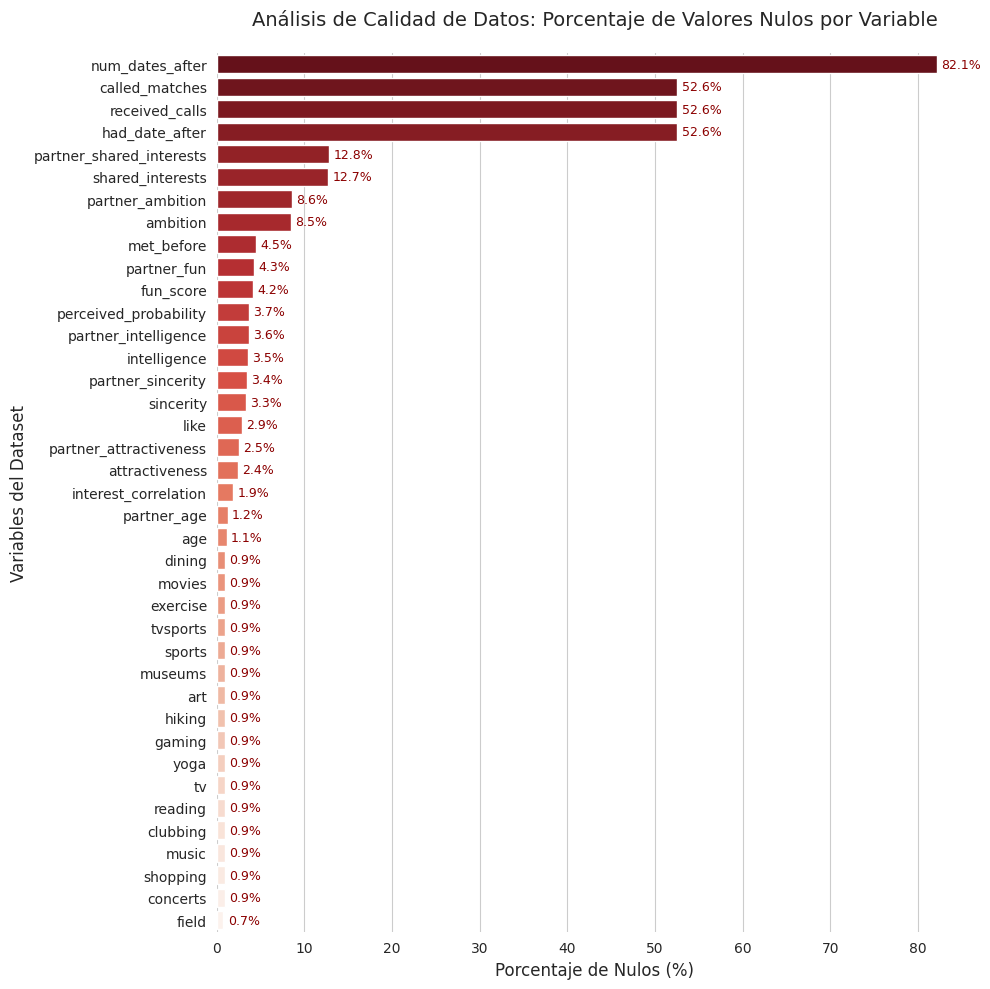

In [ ]:
#Visualización de los valores nulos en  las diferentes variables

Nans_pct_sorted = Nans_pct.sort_values(ascending=False)
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")

#Se añade una paleta a más nulos, más intensidad de color
pal = sns.color_palette("Reds_r", len(Nans_pct_sorted))

ax = sns.barplot(
    y=Nans_pct_sorted.index,
    x=Nans_pct_sorted.values,
    palette=pal
)

#Se añade el porcentaje para mejorar la visualización de los valores nulos
for i, v in enumerate(Nans_pct_sorted.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9, color='darkred')

plt.title("Análisis de Calidad de Datos: Porcentaje de Valores Nulos por Variable", fontsize=14, pad=20)
plt.xlabel("Porcentaje de Nulos (%)", fontsize=12)
plt.ylabel("Variables del Dataset", fontsize=12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
# no han habido llamadas o no han habido citas se consideran como cero.

df['called_matches'] = df['called_matches'].fillna(0)
df['received_calls'] = df['received_calls'].fillna(0)
df['num_dates_after'] = df['num_dates_after'].fillna(0)

# convertir yes/no a binario
df['had_date_after'] = df['had_date_after'].replace({1:1, 2:0})
df['had_date_after'] = df['had_date_after'].fillna(0)

In [ ]:
# para variables como atracción, sinceridad, etc se considerará sustituir los Nans con la mediana

cols_eval = [
    'attractiveness','sincerity','intelligence','fun_score','ambition','shared_interests',
    'partner_attractiveness','partner_sincerity','partner_intelligence',
    'partner_fun','partner_ambition','partner_shared_interests',
    'like','perceived_probability','interest_correlation'
]

for col in cols_eval:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df['age'] = df['age'].fillna(df['age'].median())
df['partner_age'] = df['partner_age'].fillna(df['partner_age'].median())

# met_before (binaria)
df['met_before'] = df['met_before'].fillna(0)

In [ ]:
# son poco nulos, rellenamso con la mediana
cols_interests = [
    'sports','tvsports','exercise','dining','museums','art','hiking',
    'gaming','clubbing','reading','tv','movies','concerts','music',
    'shopping','yoga'
]

for col in cols_interests:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df['field'] = df['field'].fillna("unknown")

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

numeric_cols, categorical_cols

(Index(['match', 'age', 'partner_age', 'gender', 'samerace', 'attractiveness',
        'sincerity', 'intelligence', 'fun_score', 'ambition',
        'shared_interests', 'partner_attractiveness', 'partner_sincerity',
        'partner_intelligence', 'partner_fun', 'partner_ambition',
        'partner_shared_interests', 'like', 'perceived_probability',
        'met_before', 'interest_correlation', 'sports', 'tvsports', 'exercise',
        'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading',
        'tv', 'movies', 'concerts', 'music', 'shopping', 'yoga',
        'called_matches', 'received_calls', 'had_date_after',
        'num_dates_after'],
       dtype='object'),
 Index(['field'], dtype='object'))

In [ ]:
df.columns


Index(['match', 'age', 'partner_age', 'gender', 'samerace', 'field',
       'attractiveness', 'sincerity', 'intelligence', 'fun_score', 'ambition',
       'shared_interests', 'partner_attractiveness', 'partner_sincerity',
       'partner_intelligence', 'partner_fun', 'partner_ambition',
       'partner_shared_interests', 'like', 'perceived_probability',
       'met_before', 'interest_correlation', 'sports', 'tvsports', 'exercise',
       'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading',
       'tv', 'movies', 'concerts', 'music', 'shopping', 'yoga',
       'called_matches', 'received_calls', 'had_date_after',
       'num_dates_after'],
      dtype='object')

# Análisis Factorial

In [ ]:
pip install factor_analyzer

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


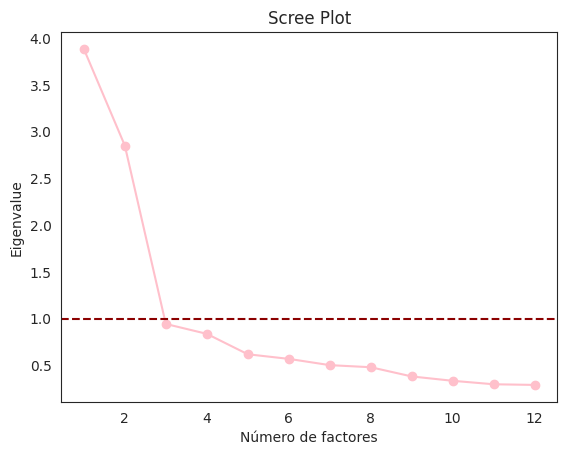

In [ ]:
from factor_analyzer import FactorAnalyzer

# Selecciona solo variables para FA (ejemplo)
cols = [
    'attractiveness', 'sincerity', 'intelligence', 'fun_score', 'ambition', 'shared_interests',
    'partner_attractiveness', 'partner_sincerity', 'partner_intelligence',
    'partner_fun', 'partner_ambition', 'partner_shared_interests'
]

X = df[cols].dropna()

# Ajuste sin rotación para obtener eigenvalues
fa = FactorAnalyzer(rotation=None)
fa.fit(X)

# Obtener eigenvalues
ev, v = fa.get_eigenvalues()

# Scree plot
plt.figure()
plt.plot(range(1, len(ev)+1), ev, marker='o', color="pink")
plt.xlabel('Número de factores')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.axhline(y=1, linestyle='--', color="darkred")  # criterio Kaiser
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


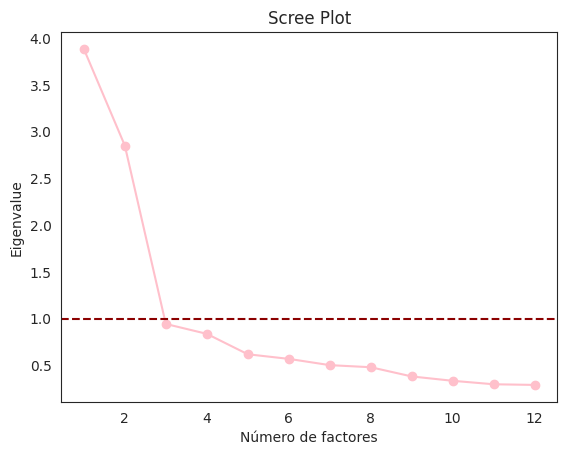

In [ ]:
# Selecciona solo variables para FA (ejemplo)
cols = [
    #
    'attractiveness', 'sincerity', 'intelligence', 'fun_score', 'ambition', 'shared_interests',
    #
    'partner_attractiveness', 'partner_sincerity', 'partner_intelligence',
    'partner_fun', 'partner_ambition', 'partner_shared_interests'
]

X = df[cols].dropna()

# Ajuste sin rotación para obtener eigenvalues
fa = FactorAnalyzer(rotation=None)
fa.fit(X)

# Obtener eigenvalues
ev, v = fa.get_eigenvalues()

# Scree plot
plt.figure()
plt.plot(range(1, len(ev)+1), ev, marker='o', color="pink")
plt.xlabel('Número de factores')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.axhline(y=1, linestyle='--', color="darkred")  # criterio Kaiser
plt.show()

# EDA

In [ ]:
# Limpiamos texto

df['field'] = df['field'].str.lower().str.strip()

# Nos quedamos con los más frecuentes

top_fields = df['field'].value_counts().nlargest(10).index

# Agrupamos el resto como other, se reducen categorías para evitar demasiadas columnas al hacer encoding.

df['field_grouped'] = df['field'].apply(lambda x: x if x in top_fields else 'other')

In [ ]:
df = pd.get_dummies(df, columns=['field_grouped'], drop_first=True)

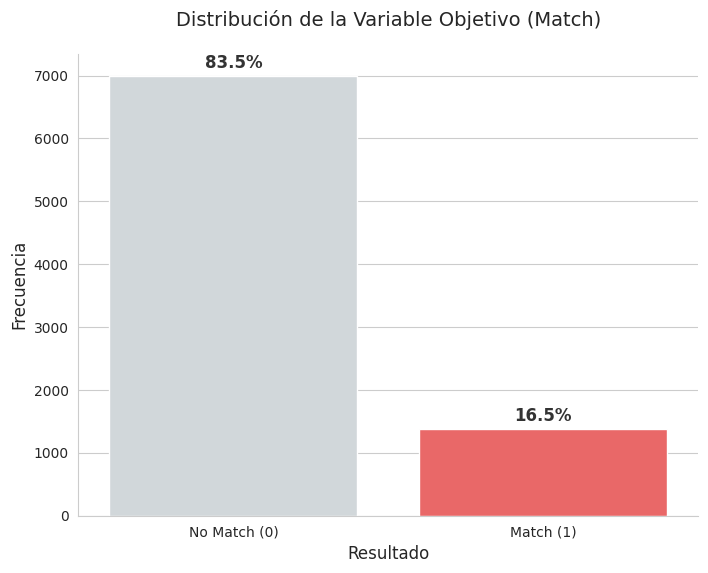

In [ ]:
#Comparativa de matches: Se observa un mayor rango de no matches (0), que de matches (1)
plt.figure(figsize=(8, 6))
colores_red = ["#CFD8DC", "#FF5252"]

ax = sns.countplot(x='match', data=df, palette=colores_red, hue='match', legend=False)

#Se decide añadir el porcentaje para mejor comparación de los matches y no match
total = len(df['match'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold', color='#333333')

plt.title("Distribución de la Variable Objetivo (Match)", fontsize=14, pad=20)
plt.xticks(ticks=[0, 1], labels=['No Match (0)', 'Match (1)'])
plt.xlabel("Resultado", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

sns.despine()
plt.show()

#El resultado indica un desbalanceo considerable

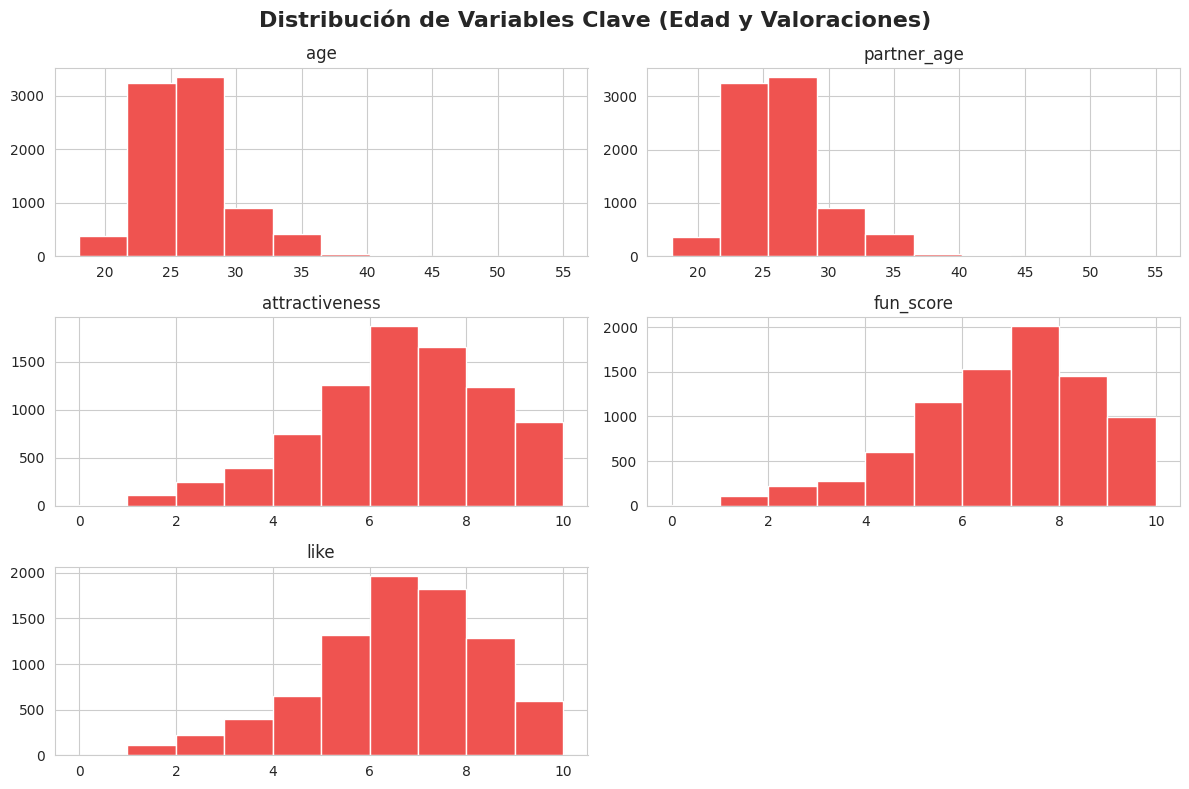

In [ ]:
#Se visualizan las variables de interés con unos histogramas, esto permitirá observar la distribución de estas.
df[["age", "partner_age", "attractiveness", "fun_score", "like"]].hist(
    figsize=(12, 8),
    color="#EF5350",
    edgecolor="white",
    grid=True
)

plt.suptitle("Distribución de Variables Clave (Edad y Valoraciones)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


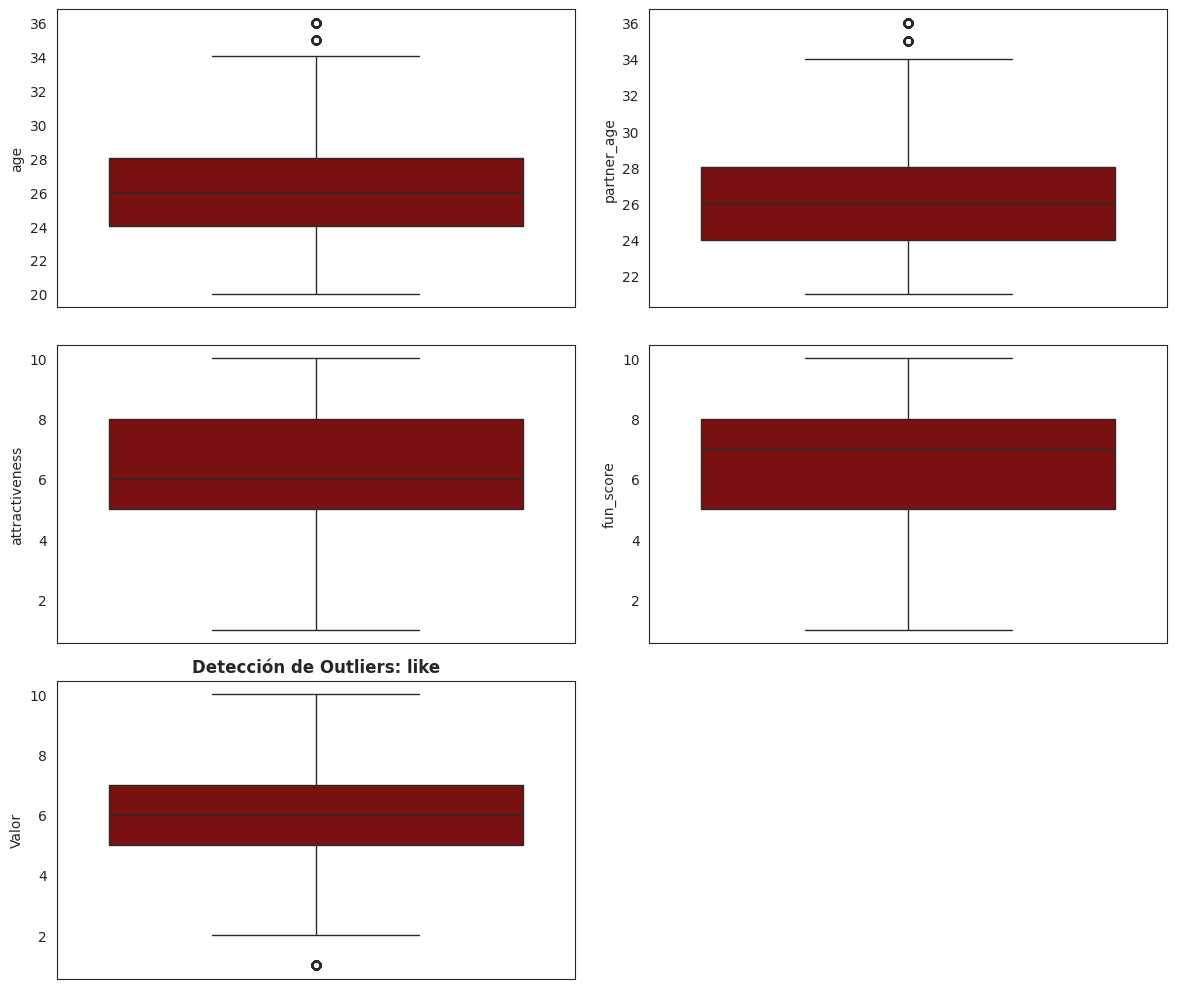

In [ ]:
#Visualización para la detección de outliers
cols_plot = ["age", "partner_age", "attractiveness", "fun_score", "like"]
sns.set_style("white")

plt.figure(figsize=(12, 10))

for i, col in enumerate(cols_plot):
    plt.subplot(3, 2, i + 1)

    sns.boxplot(
        y=df[col],
        color="darkred",
    )

plt.title(f"Detección de Outliers: {col}", fontsize=12, fontweight="bold")
plt.ylabel("Valor")
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
# Limitamos los valores extremos usando percentiles.
# En lugar de eliminar datos, se han limitado los valores extremos
# para no  perder información.
for col in cols_plot:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

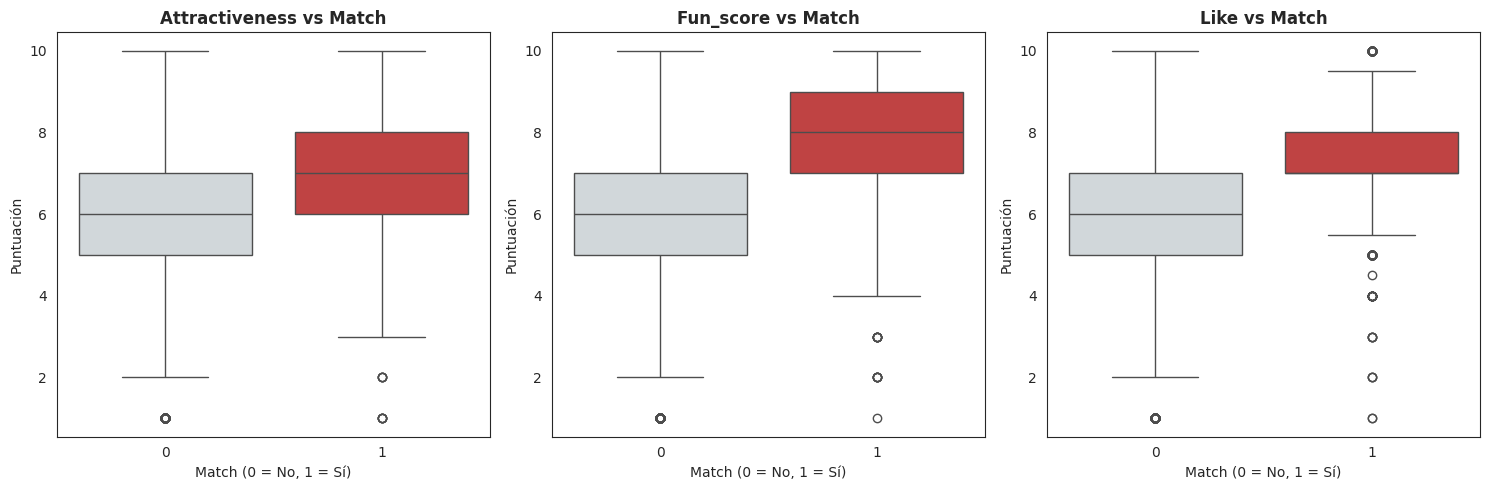

In [ ]:
#Comparativa de variables vs match
cols_vs_match = ["attractiveness", "fun_score", "like"]
plt.figure(figsize=(15, 5))
sns.set_style("white")

paleta_match = ["#CFD8DC", "#D32F2F"]

for i, col in enumerate(cols_vs_match):
    plt.subplot(1, 3, i + 1)

    sns.boxplot(
        x="match",
        y=col,
        data=df,
        palette=paleta_match,
        hue="match",
        legend=False
    )

    plt.title(f"{col.capitalize()} vs Match", fontsize=12, fontweight="bold")
    plt.xlabel("Match (0 = No, 1 = Sí)")
    plt.ylabel("Puntuación")

plt.grid(False)
plt.tight_layout()
plt.show()

#Las variables como el atractivo, la diversión y el nivel de interés influyen positivamente en la probabilidad de match.

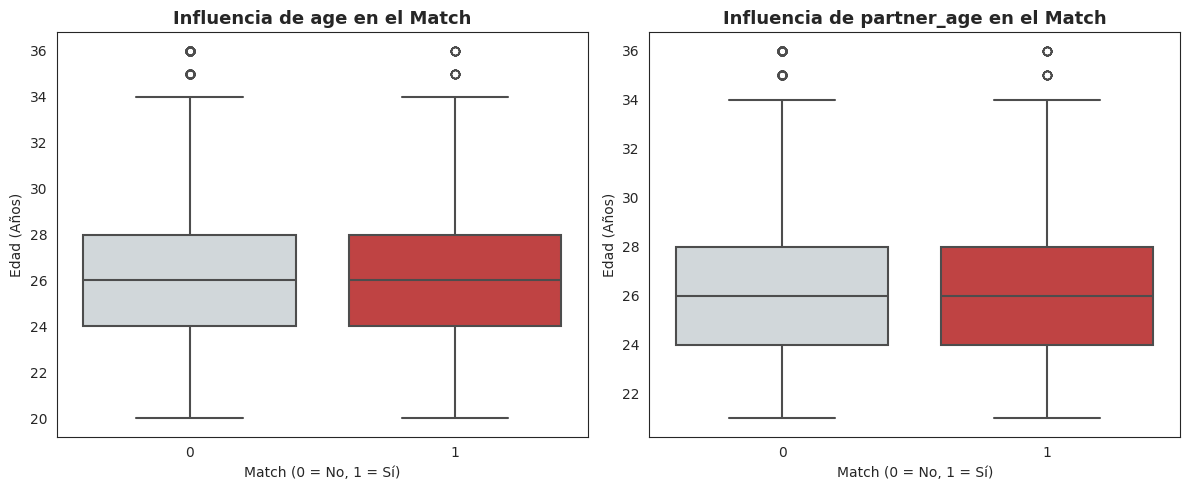

In [ ]:
#Comparativa de edad vs match
cols_age = ["age", "partner_age"]
plt.figure(figsize=(12, 5))
sns.set_style("white")

paleta_match = ["#CFD8DC", "#D32F2F"]

for i, col in enumerate(cols_age):
    plt.subplot(1, 2, i + 1)

    sns.boxplot(
        x="match",
        y=col,
        data=df,
        palette=paleta_match,
        hue="match",
        legend=False,
        linewidth=1.5
    )

    plt.title(f"Influencia de {col} en el Match", fontsize=13, fontweight="bold")
    plt.xlabel("Match (0 = No, 1 = Sí)")
    plt.ylabel("Edad (Años)")
    plt.grid(False)

plt.tight_layout()
plt.show()

#La edad no parece tener un impacto tan fuerte como otras variables, aunque puede influir ligeramente en la compatibilidad.

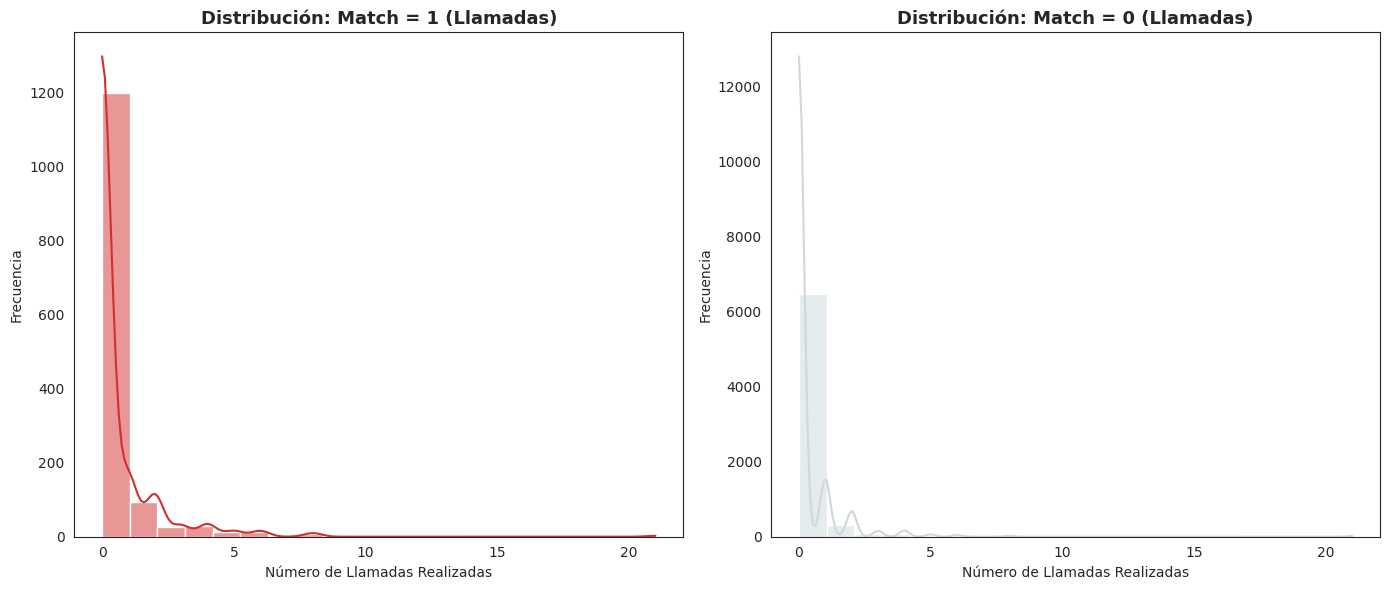

In [ ]:
#Distribución del match según las llamadas realizadas
plt.figure(figsize=(14, 6))

color_no_match = "#CFD8DC"
color_match = "#D32F2F"

plt.subplot(1, 2, 1)
sns.histplot(
    df[df["match"] == 1]["called_matches"],
    bins=20,
    kde=True,
    color=color_match,
    edgecolor="white"
)
plt.title("Distribución: Match = 1 (Llamadas)", fontsize=13, fontweight="bold")
plt.xlabel("Número de Llamadas Realizadas")
plt.ylabel("Frecuencia")
plt.grid(False)

plt.subplot(1, 2, 2)
sns.histplot(
    df[df["match"] == 0]["called_matches"],
    bins=20,
    kde=True,
    color=color_no_match,
    edgecolor="white"
)
plt.title("Distribución: Match = 0 (Llamadas)", fontsize=13, fontweight="bold")
plt.xlabel("Número de Llamadas Realizadas")
plt.ylabel("Frecuencia")
plt.grid(False)

plt.tight_layout()
plt.show()

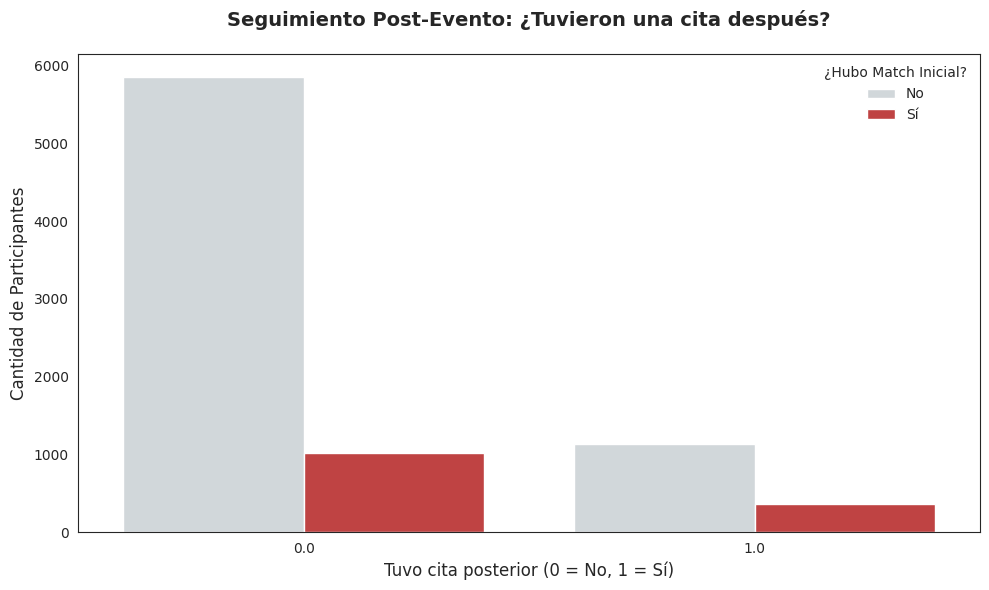

In [ ]:
#Visualización cita posteriores

plt.figure(figsize=(10, 6))
paleta_match = ["#CFD8DC", "#D32F2F"]

ax = sns.countplot(
    x="had_date_after",
    hue="match",
    data=df,
    palette=paleta_match
)

plt.title("Seguimiento Post-Evento: ¿Tuvieron una cita después?", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Tuvo cita posterior (0 = No, 1 = Sí)", fontsize=12)
plt.ylabel("Cantidad de Participantes", fontsize=12)

plt.legend(title="¿Hubo Match Inicial?", labels=["No", "Sí"], frameon=False)
plt.tight_layout()
plt.show()

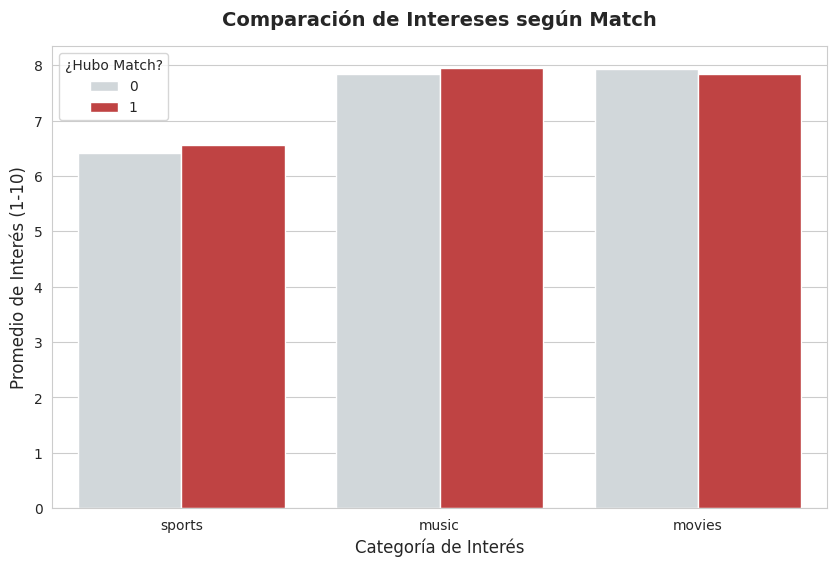

In [ ]:
#Visualización comparativa de los intereses vs match existente o no
df_plot = df.groupby("match")[["sports", "music", "movies"]].mean().reset_index()
df_plot = df_plot.melt(id_vars="match", var_name="interest", value_name="value")
plt.figure(figsize=(10, 6))

paleta_contraste = ["#CFD8DC", "#D32F2F"]

sns.barplot(
    data=df_plot,
    x="interest",
    y="value",
    hue="match",
    palette=paleta_contraste
)

plt.title("Comparación de Intereses según Match", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Categoría de Interés", fontsize=12)
plt.ylabel("Promedio de Interés (1-10)", fontsize=12)

# Mejoramos la leyenda para que sea más clara
plt.legend(title="¿Hubo Match?")
plt.show()

## Correlaciones



In [ ]:
top_fields = df['field'].value_counts().nlargest(10).index

df['field_grouped'] = df['field'].apply(lambda x: x if x in top_fields else 'other')

In [ ]:
df = pd.get_dummies(df, columns=['field_grouped'], drop_first=True)

In [ ]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

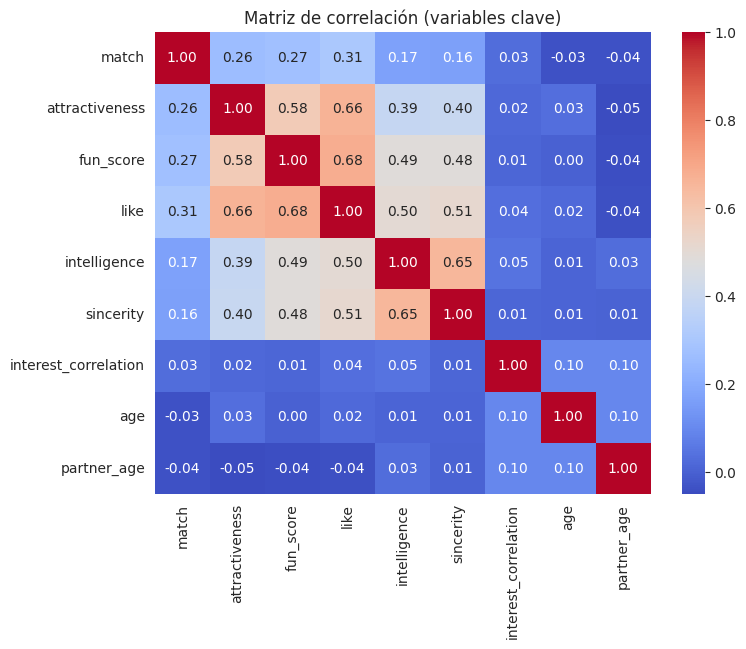

In [ ]:
cols_corr = [
    'match','attractiveness','fun_score','like',
    'intelligence','sincerity','interest_correlation',
    'age','partner_age'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[cols_corr].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Matriz de correlación (variables clave)")
plt.show()

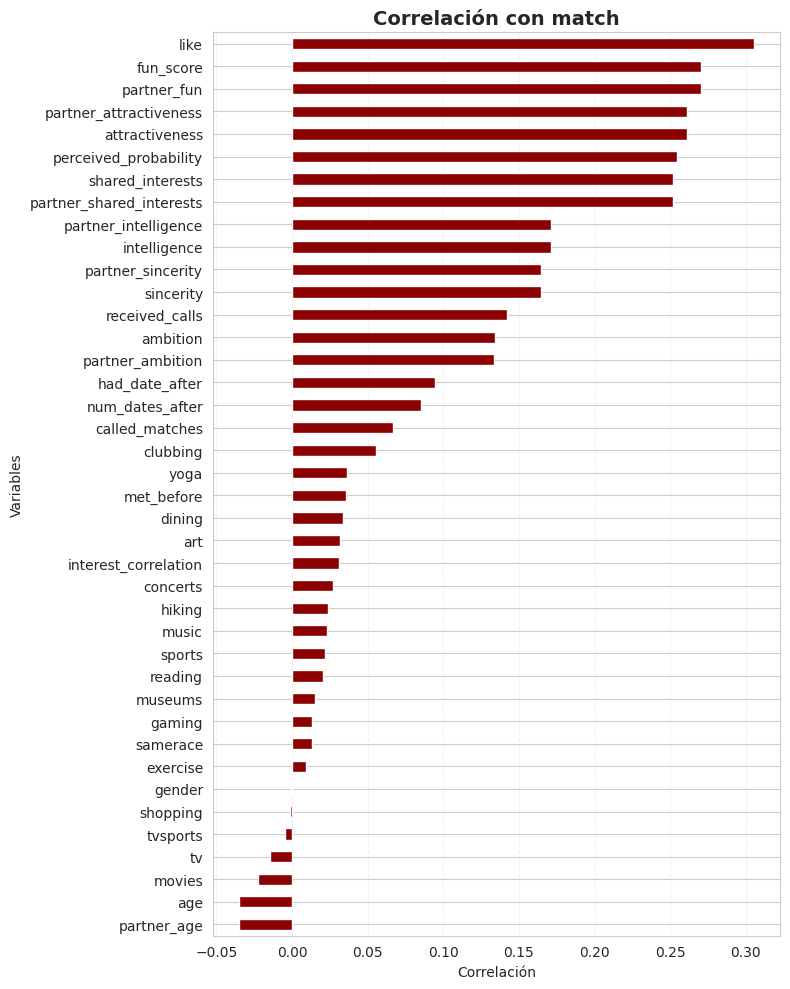

In [ ]:
#Se seleccionan aquellos datos numéricos para la visualización de la correlación con el match
df_numeric = df.select_dtypes(include=["int64", "float64"])
corr_match = df_numeric.corr()["match"].sort_values(ascending=False)

plt.figure(figsize=(8, 10))

corr_match.drop("match").plot(kind="barh", color="darkred", edgecolor="white")


plt.title("Correlación con match", fontsize=14, fontweight="bold")
plt.xlabel("Correlación")
plt.ylabel("Variables")
plt.gca().invert_yaxis() #Se gira las barras para que estén en orden
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.show()

#Las variables más correlacionadas con el match suelen ser las relacionadas con evaluaciones personales como atractivo,
#diversión y nivel de interés.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleccionamos solo variables numéricas
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Variables a excluir
variables_excluidas = [
    'match',  # variable objetivo
    'called_matches',
    'received_calls',
    'had_date_after',
    'num_dates_after'
]

# Creamos X para VIF
X = df_numeric.drop(columns=variables_excluidas, errors='ignore')

# Calculamos VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

#multicolinealidad altas en muchas variables porque mide cosas similiares como dos edades
#la edad de una persona (age) y la partner_age de la otra persona.
#también estan las variables muy relaciones como sports  y exercise.

,Variable,VIF
0,age,54.602604
1,partner_age,50.527092
2,gender,2.973253
3,samerace,1.722605
4,attractiveness,22.461212
5,sincerity,36.889079
6,intelligence,57.032332
7,fun_score,28.737589
8,ambition,29.682148
9,shared_interests,16.568518


Aunque el análisis del VIF muestra valores elevados en algunas variables, especialmente en aquellas relacionadas con evaluaciones del participante y del partner, se ha decidido mantenerlas en el modelo. Esto se debe a que no son variables redundantes, sino que representan perspectivas diferentes dentro de la interacción, lo cual es relevante en un contexto de comportamiento humano. Además, se tiene en cuenta que modelos como Random Forest son menos sensibles a la multicolinealidad.

# 3. Clustering


In [ ]:
# Se importan las librerias necesarias para aplicar K-Means, Elbow, etc.
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
#Se realiza preprocesamiento para luego realizar el proceso de clustering
features = [
    'match', 'age', 'partner_age', 'gender', 'samerace', 'attractiveness',
        'sincerity', 'intelligence', 'fun_score', 'ambition',
        'shared_interests', 'partner_attractiveness', 'partner_sincerity',
        'partner_intelligence', 'partner_fun', 'partner_ambition',
        'partner_shared_interests', 'like', 'perceived_probability',
        'met_before', 'interest_correlation', 'sports', 'tvsports', 'exercise',
        'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading',
        'tv', 'movies', 'concerts', 'music', 'shopping', 'yoga',
        'called_matches', 'received_calls', 'had_date_after',
        'num_dates_after'
]

X = df[features].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns = features,
    index = X.index
)

X_scaled.head(5)
#Se ha aplicado standard scaler para normalizar las variables.
#De esta manera no influirán en las distancias del algoritmo en K-Means

,match,age,partner_age,gender,samerace,attractiveness,sincerity,intelligence,fun_score,ambition,...,tv,movies,concerts,music,shopping,yoga,called_matches,received_calls,had_date_after,num_dates_after
0,-0.444103,-1.577485,0.198257,-1.001314,-0.809448,-0.096881,1.069539,-0.233294,0.299713,-0.463772,...,1.465166,1.228434,1.478445,0.643455,0.910838,-1.233303,0.535164,0.499064,-0.466652,-0.304402
1,-0.444103,-1.577485,-1.293922,-1.001314,-0.809448,0.422893,0.485285,-0.233294,0.822993,-1.046102,...,1.465166,1.228434,1.478445,0.643455,0.910838,-1.233303,0.535164,0.499064,-0.466652,-0.304402
2,2.251730,-1.577485,-1.293922,-1.001314,1.235409,-0.616656,0.485285,1.078759,0.822993,-1.046102,...,1.465166,1.228434,1.478445,0.643455,0.910838,-1.233303,0.535164,0.499064,-0.466652,-0.304402
3,2.251730,-1.577485,-0.995486,-1.001314,-0.809448,0.422893,-0.683222,0.422733,0.299713,-0.463772,...,1.465166,1.228434,1.478445,0.643455,0.910838,-1.233303,0.535164,0.499064,-0.466652,-0.304402
4,2.251730,-1.577485,-0.697051,-1.001314,-0.809448,-0.616656,-0.683222,-0.233294,0.299713,-0.463772,...,1.465166,1.228434,1.478445,0.643455,0.910838,-1.233303,0.535164,0.499064,-0.466652,-0.304402


In [ ]:
#Se selecciona un range a partir del 2 (dado que se necesita un minimo de 2 pruebas) y se limita hasta 11 para incluir el 10
k_values = range(2,11)

inertias = []
silhouettes = []

for k in k_values:
  km = KMeans(n_clusters = k, random_state = 42, n_init = "auto")
  labels = km.fit_predict(X_scaled)
  inertias.append(km.inertia_)
  silhouettes.append(silhouette_score(X_scaled, labels))

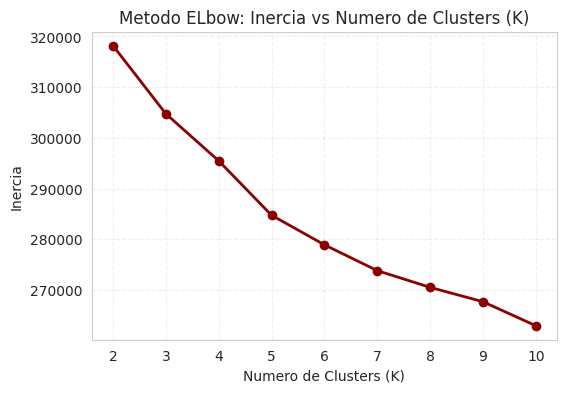

In [ ]:
#Se visualiza la relacion entre la inercia y las K segun el metodo del codo

plt.figure(figsize = (6,4))

plt.plot(k_values, inertias, marker = "o", linewidth = 2, color = "darkred")
plt.title("Metodo ELbow: Inercia vs Numero de Clusters (K)")
plt.xlabel("Numero de Clusters (K)")
plt.ylabel("Inercia")

plt.grid(linestyle ="--", alpha = 0.3)
plt.show()

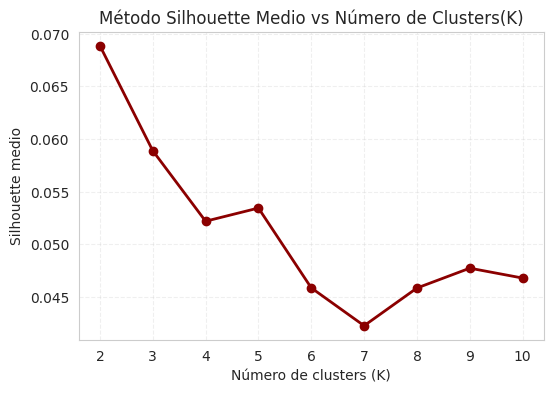

In [ ]:
plt.figure(figsize = (6,4))

plt.plot(k_values, silhouettes, marker = "o", linewidth = 2, color = "darkred")
plt.title("Método Silhouette Medio vs Número de Clusters(K)", fontsize = 12)
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette medio")

plt.grid(linestyle = "--", alpha = 0.3)
plt.show()

El método silhouette servirá para constrastar el valor obtenido en el método elbow. Este método ayuda a analizar la calidad de los grupos según los diferentes valores de la K. Es decir, evalua la separación de los clusteres entre ellos .

Según el resultado de la gráfica Silhouette, los valores K alcanzan números relativamente altos. Esto se interpreta como que existe una separación adecuada entre los diferentes grupos. Los valores óptimos obtenidos varían entre K=2 y K=3. La curva en el Elbow Method va decreciendo sin tener una rotura clara.

Por otro lado, el método Elbow muestra una reducción progresiva de la inercia a medida que aumenta el número de clusters, sin evidenciar un punto de inflexión claramente definido. Esto sugiere que no existe una segmentación natural fuerte en los datos.

En consecuencia, al aumentar el número de clusters se produce una mayor superposición entre los grupos, reduciendo la calidad del agrupamiento. Por ello, en este caso, un número menor de clusters (K = 2 o K = 3) parece ajustarse mejor a la estructura subyacente de los datos.

In [ ]:
#Aplicacion del K-Means
k_final = 2

kmeans = KMeans(n_clusters = k_final, random_state = 42, n_init = "auto")
labels = kmeans.fit_predict(X_scaled)

df["clusters"] = labels

pd.Series(labels).value_counts().sort_index()

#al distribuir los datos en 2 clusters, el numero de inputs que componen cada uno de los clusters
#se puede observar que es relativamente balanceado

,count
0,4279
1,4098


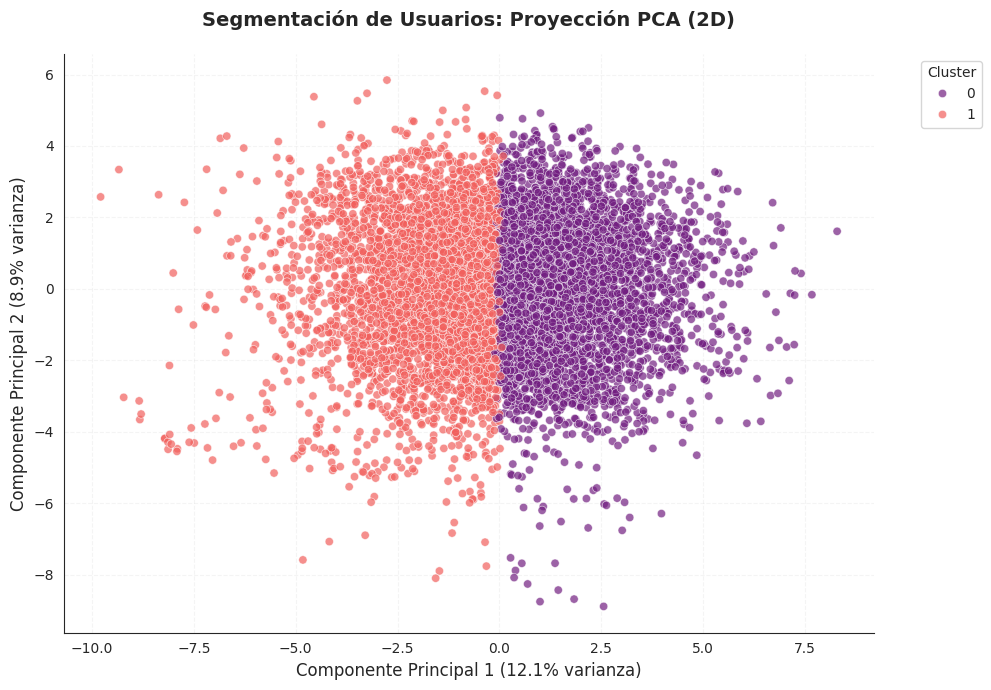

In [ ]:
#Segmentación de los usuarios según el PCA a 2D
from sklearn.decomposition import PCA

#pca = PCA(n_components=2, random_state=42)
#X_pca = pca.fit_transoform(X_scaled)
#Se reduce a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": labels
})

plt.figure(figsize=(10, 7))
sns.set_style("white")

ax = sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="cluster",
    data=pca_df,
    palette="magma",
    alpha=0.7
)

plt.title("Segmentación de Usuarios: Proyección PCA (2D)", fontsize=14, fontweight="bold", pad=20)
plt.xlabel(f"Componente Principal 1 ({var_exp[0]:.1f}% varianza)", fontsize=12)
plt.ylabel(f"Componente Principal 2 ({var_exp[1]:.1f}% varianza)", fontsize=12)

plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(linestyle="--", alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

 # 4. Modelos

## 4.1. Modelo de Regresión

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Eliminamos variables de comportamiento posterior (leakage)
# para evitar usar información del futuro en el modelo

df_model = df.drop(columns=[
    'called_matches',
    'received_calls',
    'had_date_after',
    'num_dates_after'
], errors='ignore')

# 2. encoding
df_model = pd.get_dummies(df_model, columns=['field'], drop_first=True)

In [ ]:
# Variable objetivo
y = df_model['match']

# Variables predictoras
X = df_model.drop(columns=['match'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model_log = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_log.fit(X_train, y_train)

y_pred_log = model_log.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

En un principio no se utilizó el parámetro class_weight='balanced', obteniéndose una accuracy de 0,89. Sin embargo, en este caso es más importante prestar atención al recall, que indica cuántos de los match reales son correctamente detectados por el modelo, y no únicamente a la accuracy. Además, es fundamental analizar la matriz de confusión para entender mejor los errores del modelo.

Dado que en el dataset la mayoría de los casos corresponden a no-match, el modelo inicial estaba desbalanceado y tendía a predecir la clase mayoritaria. Al aplicar class_weight='balanced', se observa una mejora significativa en la detección de la clase minoritaria (match), aumentando el recall de 0.39 a 0.79. Asimismo, los falsos negativos se reducen de 168 a 59, lo que indica una mejor capacidad para identificar matches reales.

Aunque la accuracy global disminuye, el modelo se vuelve más equilibrado y capaz de detectar correctamente los casos de match, lo cual es especialmente relevante en problemas desbalanceados.

Esto demuestra que la accuracy no es la métrica más adecuada en este tipo de problemas, siendo el recall y el F1-score indicadores más representativos del rendimiento real del modelo.

## 4.2. Modelo de Clasificación

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#SVm
model_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced'))
])

model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

El modelo SVM presenta un rendimiento similar al de la regresión logística con balanceo de clases, logrando un recall de 0.76 en la detección de matches. Sin embargo, se observa un número elevado de falsos positivos, lo que reduce la precisión del modelo.

En comparación con la regresión logística, el SVM muestra un rendimiento ligeramente inferior en la detección de la clase minoritaria, por lo que no representa una mejora significativa.

In [ ]:
# Convertimos todo a numérico y luego a numpy
X_train_xgb = X_train.apply(pd.to_numeric, errors='coerce').astype(float).to_numpy()
X_test_xgb = X_test.apply(pd.to_numeric, errors='coerce').astype(float).to_numpy()

y_train_xgb = np.array(y_train)
y_test_xgb = np.array(y_test)

# Ajuste por desbalance de clases
scale_pos_weight = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()

# Modelo XGBoost
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

# Entrenamiento
model_xgb.fit(X_train_xgb, y_train_xgb)

# Predicciones
y_pred_xgb = model_xgb.predict(X_test_xgb)

# Resultados
print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test_xgb, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_xgb, y_pred_xgb))

## 4.3. Modelo Random Forest (Opcional)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Aunque Random Forest presenta una alta accuracy 0.86, su rendimiento en la detección de la clase minoritaria es bajo, con un recall de 0.22. Esto indica que el modelo no logra identificar correctamente la mayoría de los casos de match.

En comparación, la regresión logística con class_weight='balanced' ofrece un mejor equilibrio entre las clases, alcanzando un recall de 0.79.

Por tanto, a pesar de su menor accuracy, la regresión logística resulta ser el modelo más adecuado para este problema, ya que permite detectar de forma más efectiva los casos de match, que son el objetivo principal del análisis.

#5. Conclusiónes


In [ ]:
# Resultados
results = pd.DataFrame({
    "Modelo": [
        "Logistic Regression (balanced)",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.75,
        0.73,
        0.86,
        0.79
    ],
    "Recall (match)": [
        0.79,
        0.76,
        0.22,
        0.75
    ],
    "F1-score (match)": [
        0.51,
        0.48,
        0.34,
        0.54
    ]
})

results.sort_values(by="Recall (match)", ascending=False)